In [1]:
import sqlite3
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
conn = sqlite3.connect(r"C:\Users\Sumit Mathpal\Desktop\ML\Invoice_intelligent_system\Freight_cost_prediction\data\inventory.db")

In [3]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'",conn)
for table in tables["name"]:
    print(f"Table name {table}")
    display(pd.read_sql(f"SELECT * from {table} limit 5", conn))

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [4]:
purchase_agg_df = pd.read_sql_query("""
SELECT p.PONumber, 
count(distinct p.Brand) as total_brands, 
sum(p.Quantity)  as total_item_qunatity, 
sum(p.Dollars) as total_item_dollers,
avg(julianday(p.ReceivingDate) -  julianday(p.PODate)) as avg_receiving_delay
from  purchases as p 
group by p.PONumber

""",conn)

In [5]:
purchase_agg_df 

,PONumber,total_brands,total_item_qunatity,total_item_dollers,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [6]:
pd.read_sql_query("""
SELECT
    vi.PONumber as po_number,
    vi.Quantity as invoice_quantity,
    vi.Dollars as invoice_Dollars,
    vi.Freight as invoice_Freight,

(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,

(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as day_to_pay

FROM vendor_invoice as vi
""", conn)

,po_number,invoice_quantity,invoice_Dollars,invoice_Freight,days_po_to_invoice,day_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [7]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT 
        p.PONumber, 
        COUNT(DISTINCT p.Brand) AS total_brands, 
        SUM(p.Quantity) AS total_item_quantity, 
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases AS p 
    GROUP BY p.PONumber  
)

SELECT
    vi.PONumber AS po_number,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_Dollars,
    vi.Freight AS invoice_Freight,

    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS day_to_pay,

    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars, 
    pa.avg_receiving_delay

FROM vendor_invoice AS vi
LEFT JOIN purchase_agg AS pa
    ON vi.PONumber = pa.PONumber
""", conn)

In [8]:
df


,po_number,invoice_quantity,invoice_Dollars,invoice_Freight,days_po_to_invoice,day_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [9]:
df.isnull().sum()

po_number              0
invoice_quantity       0
invoice_Dollars        0
invoice_Freight        0
days_po_to_invoice     0
day_to_pay             0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [10]:
df.dtypes

po_number                int64
invoice_quantity         int64
invoice_Dollars        float64
invoice_Freight        float64
days_po_to_invoice     float64
day_to_pay             float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [11]:
def create_invoice_risk_label(row):
    #Invoiced mismatch with item-level total
    if(abs(row["invoice_Dollars"]-row["total_item_dollars"])>5):
        return 1
    #Abnormal high receving delay
    if row["avg_receiving_delay"]>10:
        return 1
    return 0
df["flag_invoiced"] = df.apply(create_invoice_risk_label,axis=1)
df["flag_invoiced"].value_counts()

flag_invoiced
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoiced'>

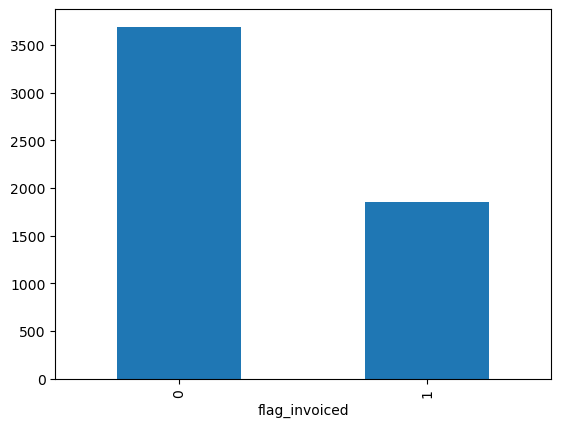

In [12]:
df["flag_invoiced"].value_counts().plot(kind="bar")

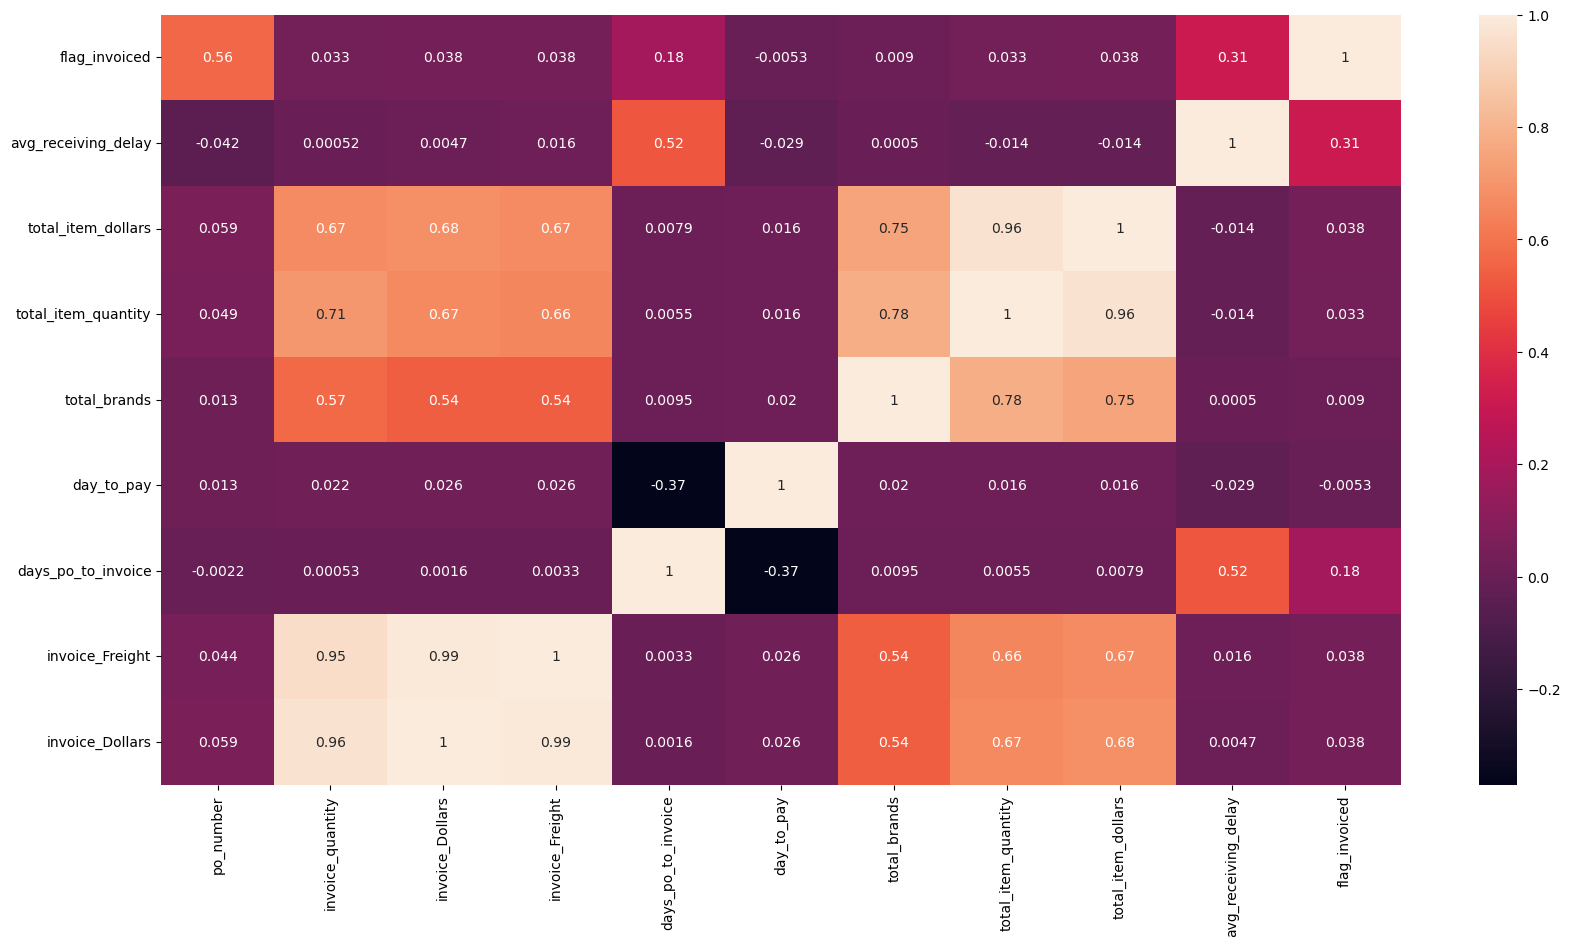

In [13]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr().iloc[:1:-1],annot=True)
plt.show()

In [14]:
flagged = df[df["flag_invoiced"]==1]
normal = df[df["flag_invoiced"]==0]

In [15]:
significant_features = []
non_significant_features = []
results =[]


In [16]:
metrics = ["invoice_quantity","invoice_Dollars","invoice_Freight","days_po_to_invoice","day_to_pay","total_brands","total_item_quantity","total_item_dollars","avg_receiving_delay"]

In [17]:
df.columns

Index(['po_number', 'invoice_quantity', 'invoice_Dollars', 'invoice_Freight',
       'days_po_to_invoice', 'day_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay',
       'flag_invoiced'],
      dtype='object')

In [18]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()
    t_stat,p_value = ttest_ind(flagged[metric].dropna(),normal[metric].dropna(),equal_var=False)
    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric":metric,"flagged_mean":flagged_mean.round(2),"normal_mean":normal_mean.round(2),"p_value":p_value.round(3)})
    else:
        non_significant_features.append(metric)
        print(metric)
        print({ "metric":metric,"flagged_mean":flagged_mean.round(2),"normal_mean":normal_mean.round(2),"p_value":p_value.round(3)})
    
        

day_to_pay
{'metric': 'day_to_pay', 'flagged_mean': np.float64(35.42), 'normal_mean': np.float64(35.49), 'p_value': np.float64(0.692)}
total_brands
{'metric': 'total_brands', 'flagged_mean': np.float64(42.29), 'normal_mean': np.float64(40.82), 'p_value': np.float64(0.508)}


In [19]:
 non_significant_features

['day_to_pay', 'total_brands']

In [20]:
significant_features

['invoice_quantity',
 'invoice_Dollars',
 'invoice_Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [21]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_Dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'invoice_Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [22]:
X =  df[["invoice_quantity","invoice_Dollars","invoice_Freight","total_brands","total_item_quantity","days_po_to_invoice","total_item_dollars"]]
y=df["flag_invoiced"]

In [23]:
X

,invoice_quantity,invoice_Dollars,invoice_Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
0,6,214.26,3.47,1,6,14.0,214.26
1,15,140.55,8.57,2,15,16.0,140.55
2,5,106.60,4.61,1,5,16.0,106.60
3,10100,137483.78,2935.20,81,10100,23.0,137483.78
4,1935,15527.25,429.20,29,1935,14.0,15527.25
...,...,...,...,...,...,...,...
5538,90,1563.00,8.60,2,223,16.0,6823.18
5539,4617,37300.48,186.50,110,24747,18.0,149007.56
5540,9848,202815.78,932.95,5,180,11.0,2559.72
5541,24747,149007.56,819.54,83,43240,14.0,318075.65


In [24]:
X.shape

(5543, 7)

In [25]:
X.describe().round()

,invoice_quantity,invoice_Dollars,invoice_Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0


In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
Scaler = StandardScaler()
X_train_scaled=Scaler.fit_transform(X_train)
X_test_scaled =Scaler.transform(X_test)

In [28]:
X_train_scaled

array([[-0.41905146, -0.41337729, -0.41423659, ..., -0.42429059,
        -0.45029539, -0.41941635],
       [-0.41822208, -0.4128181 , -0.41370306, ...,  1.75773241,
        -0.45029539,  1.9383109 ],
       [-0.41863677, -0.41117485, -0.41246751, ...,  0.10171067,
        -0.13078671, -0.06047013],
       ...,
       [-0.42029553, -0.41500167, -0.41590738, ..., -0.41281111,
        -1.08931275, -0.40407254],
       [-0.41518102, -0.41066312, -0.41182166, ..., -0.39105678,
        -1.72833012, -0.38342278],
       [ 0.72272765,  0.89559406,  0.87141635, ...,  0.74633325,
        -0.45029539,  0.92175951]])

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [30]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled,y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

RandomForestClassifier(random_state=42)

In [31]:
model2

DecisionTreeClassifier(random_state=42)

In [32]:
model3

RandomForestClassifier(random_state=42)

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n {model_name} Performance:")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    return acc

In [34]:
print(evaluate_model(model1,X_test_scaled, y_test, "LogisticRegression"))
print(evaluate_model(model2,X_test_scaled,y_test,"DecisiionTree"))
print(evaluate_model(model3,X_test_scaled,y_test,"RandomForest"))


 LogisticRegression Performance:
Accuracy : 0.6582506762849414
Precision: 0.5609756097560976
Recall   : 0.059895833333333336
F1 Score : 0.10823529411764705
0.6582506762849414

 DecisiionTree Performance:
Accuracy : 0.8115419296663661
Precision: 0.7358490566037735
Recall   : 0.7109375
F1 Score : 0.7231788079470198
0.8115419296663661

 RandomForest Performance:
Accuracy : 0.8764652840396754
Precision: 0.942652329749104
Recall   : 0.6848958333333334
F1 Score : 0.7933634992458521
0.8764652840396754


In [35]:
model3.feature_importances_

array([0.15137936, 0.15124851, 0.14480642, 0.07920458, 0.17669413,
       0.07717963, 0.21948736])

In [36]:
feature_importance = pd.DataFrame({
    "features":X_train.columns,
    "importance":model3.feature_importances_
}).sort_values(by="importance",ascending=False)

feature_importance

,features,importance
6,total_item_dollars,0.219487
4,total_item_quantity,0.176694
0,invoice_quantity,0.151379
1,invoice_Dollars,0.151249
2,invoice_Freight,0.144806
3,total_brands,0.079205
5,days_po_to_invoice,0.077180


In [37]:
X =  df[["invoice_quantity","invoice_Dollars","invoice_Freight","total_item_quantity","total_item_dollars"]]
y = df["flag_invoiced"]

In [38]:
X

,invoice_quantity,invoice_Dollars,invoice_Freight,total_item_quantity,total_item_dollars
0,6,214.26,3.47,6,214.26
1,15,140.55,8.57,15,140.55
2,5,106.60,4.61,5,106.60
3,10100,137483.78,2935.20,10100,137483.78
4,1935,15527.25,429.20,1935,15527.25
...,...,...,...,...,...
5538,90,1563.00,8.60,223,6823.18
5539,4617,37300.48,186.50,24747,149007.56
5540,9848,202815.78,932.95,180,2559.72
5541,24747,149007.56,819.54,43240,318075.65


In [39]:
X.columns

Index(['invoice_quantity', 'invoice_Dollars', 'invoice_Freight',
       'total_item_quantity', 'total_item_dollars'],
      dtype='object')

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled= Scaler.transform(X_test)
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)
evaluate_model(model3,X_test_scaled,y_test,"Random forest classifier")



 Random forest classifier Performance:
Accuracy : 0.8845807033363391
Precision: 0.935374149659864
Recall   : 0.7161458333333334
F1 Score : 0.8112094395280236


0.8845807033363391

In [41]:
param_grid = {
    "n_estimators" :[100,200,300],
    "max_depth" : [None,4,5,6],
    "min_samples_split"  : [2,3,5],
    "min_samples_leaf":[1,2,5],
    "criterion":["gini","entropy"]
}

In [42]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42,n_jobs=-1)
scorer = make_scorer(f1_score)
grid_search = GridSearchCV(estimator=rf,param_grid=param_grid,scoring=scorer,cv=5,verbose=2,n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)
evaluate_model(grid_search,X_test_scaled,y_test,"Random Forest Classifier")



Fitting 5 folds for each of 216 candidates, totalling 1080 fits

 Random Forest Classifier Performance:
Accuracy : 0.8881875563570785
Precision: 0.9577464788732394
Recall   : 0.7083333333333334
F1 Score : 0.8143712574850299


0.8881875563570785

In [43]:
from sklearn.metrics import confusion_matrix

In [44]:
confusion_matrix(grid_search.predict(X_test_scaled),y_test)

array([[713, 112],
       [ 12, 272]])

In [45]:
confusion_matrix(model3.predict(X_test_scaled),y_test)

array([[706, 109],
       [ 19, 275]])

In [46]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}